# Esercizi - Lezione 2

## Numpy
Possiamo trattare le matrici con il modulo `numpy` per esempio:

In [ ]:
import numpy as np
np.array([[1,0],[0,-1]], dtype =np.float32)

array([[ 1.,  0.],
       [ 0., -1.]], dtype=float32)

## Scipy
Molto utile per calcolare fit e operazioni complesse anche verso il ML. Per esempio nell'approssimazione della matrice hesssiana col metodo BFGS o altri.

## TensorFlow
Molto importante per il ML, si può estendere con keras.

Con tf.GradientTape() possiamo calcolare gradienti e derivate molto facilmente.

Posso anche compilare una funzione tramite:

In [ ]:
import tensorflow as tf

In [8]:
@tf.function
def f(x):
    print("Prima volta comparirà questo print, dalla seconda in poi no perché verrrà compilata")
    return tf.reduce_sum(x)


f(tf.constant([1,2,3]))


Prima volta comparirà questo print, dalla seconda in poi no perché verrrà compilata


<tf.Tensor: shape=(), dtype=int32, numpy=6>

In [7]:
f(tf.constant([-1,2,-4]))


<tf.Tensor: shape=(), dtype=int32, numpy=-3>

# Esercizi
## Esercizio 1 - numpy array

In [16]:
import numpy as np
a = np.array([[0.5, -1],[-1, 2]], dtype=np.float32)

print(a.shape)
print(a.ndim)

b = a.flatten().copy()

for i in range(len(b)):
    if i % 2 == 0:
        b[i] = 0

print(b)

# alternativamente potevo fare

b[0::2] = 0

(2, 2)
2
[ 0. -1.  0.  2.]


## Esercizio 2 - numpy performance


In [31]:
import random as rd

N = rd.randint(1, 10)
print(N)

v = np.zeros(N, dtype=np.float64)
for i in range(len(v)):
    v[i] = rd.random()
    

print(v)
A = np.zeros((N,N))
print(A)

# definisco un dot product con funzioni native
def dot(a, v):
    w = np.zeros(v.shape) # crea un vettore risultante della stessa dimenzione di v
    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            w[i] += a[i][j] * v[j]
    return w


6
[0.73411177 0.34342259 0.72929249 0.06691421 0.96317652 0.03452946]
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [32]:
N = 5000
v = np.random.rand(N).astype(np.float64)
A = np.random.rand(N, N).astype(np.float64)

In [33]:
%%timeit #stima valore medio e dev standard della funzione, ripeteendolo un tot di volte
w1 = dot(A, v)

8.86 s ± 39.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [34]:
%%timeit
w2 = A.dot(v)

4.98 ms ± 9.27 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [48]:
# questo e' molto impressionante pero posso anche migliorare compilando il codice con numba
import numba as nb

@nb.njit # compilo e ridefinisco la funzione
def dot2(a, v):
    w = np.zeros(v.shape) # crea un vettore risultante della stessa dimenzione di v
    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            w[i] += a[i][j] * v[j]
    return w

In [49]:
%%timeit
w3 = dot2(A, v) # già molto meglio

30.3 ms ± 36.1 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [53]:
# posso migliorare ulteriormente facendo:
@nb.njit("float64[:](float64[:,:],float64[:])", parallel = True)
def dot3(a, v):
    w = np.zeros(v.shape) # crea un vettore risultante della stessa dimenzione di v
    for i in nb.prange(a.shape[0]): #parallelizza
        for j in nb.prange(a.shape[1]):
            w[i] += a[i][j] * v[j]
    return w

In [54]:
%%timeit
w4 = dot3(A, v) # njit funziona molto bene perché e' python basico e uso un solo dtype per cui non si può fare sempre

6.55 ms ± 134 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [46]:
%%timeit
w4 = A.dot(v)

4.99 ms ± 48.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Excursus: Poetry
Poetry e' un pacchetto molto utile per configurare un progetto con dipendenze, readme, codice sorgente, test etc

In [24]:
! pip install poetry

  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached cffi-2.0.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.7 MB/s  0:00:00m0:00:01
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.3 MB/s  0:00:00
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
Using cached cffi-2.0.0-cp312-cp312-macosx_11_0_arm64.whl (181 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11

e con 
`poetry new <project-name>`
si crea una dir

```
poetry-demo
├── pyproject.toml
├── README.md
├── src
│   └── poetry_demo
│       └── __init__.py
└── tests
    └── __init__.py
```
con tutto già settato molto figo provalo

## Esercizio 3 - matplotlib

In [60]:
import matplotlib.pyplot as plt

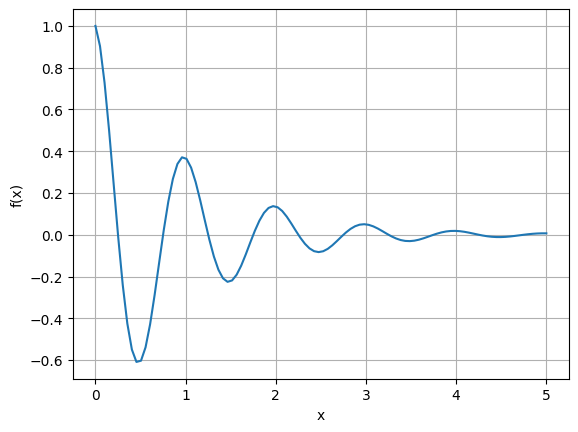

In [116]:
def f(x):
    return np.exp(-x)*np.cos(2 * np.pi * x)

x = np.linspace(0, 5, 100)
y = f(x)

plt.grid(True)

plt.xlabel('x')
plt.ylabel('f(x)')

plt.plot(x, f(x))


## Esercizio 4 - Scatter Plot

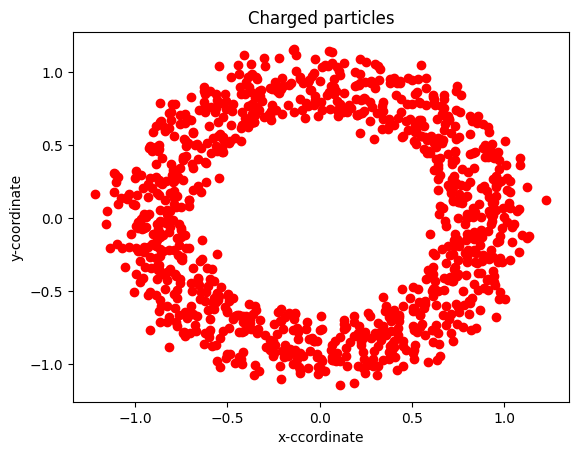

In [84]:
data = np.loadtxt('data4.dat')

plt.xlabel('x-ccordinate')
plt.ylabel('y-coordinate')
plt.title('Charged particles')

plt.plot(data[:,0], data[:,1], 'or')
plt.savefig('output.png', dpi = 300)

## Esercizio 5 - Plot di funzioni

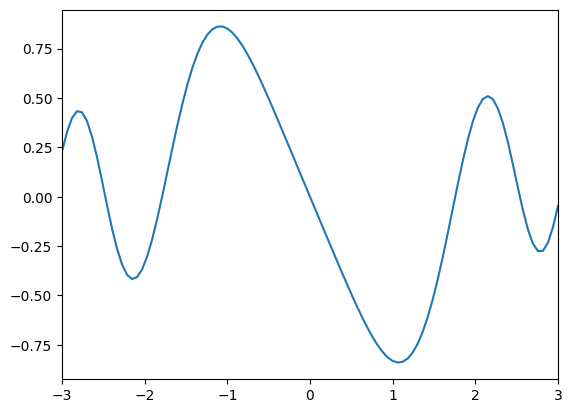

In [118]:
def f2(x):
    return -np.sin(x*x)/x + 0.01 * x*x

x2 = np.linspace(-3,3, 100)
y2 = f2(x2)
dat = np.array((x2,y2))

np.savetxt('output.dat', dat.T) # transpose to get 2 elements per line, or use np.vstack([x2, y2]).T


plt.xlim([-3,3])
# mettere label, titolo etc

plt.plot(x2, y2)

## Esercizio 6 - Pandas

In [111]:
import pandas as pd

In [113]:

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                        na_values='?', comment='\t',
                        sep=' ', skipinitialspace=True)


raw_dataset.mean()

MPG               23.514573
Cylinders          5.454774
Displacement     193.425879
Horsepower       104.469388
Weight          2970.424623
Acceleration      15.568090
Model Year        76.010050
Origin             1.572864
dtype: float64

In [115]:
raw_dataset[raw_dataset['Cylinders'] == 3] 

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
71,19.0,3,70.0,97.0,2330.0,13.5,72,3
111,18.0,3,70.0,90.0,2124.0,13.5,73,3
243,21.5,3,80.0,110.0,2720.0,13.5,77,3
334,23.7,3,70.0,100.0,2420.0,12.5,80,3


## Esercizio 7 - Polynomial fits con Numpy

In [2]:
def true_func(x):
    return np.cos(1.5 * np.pi * x)

# mean square error loss function
def MSE_loss(x, y, fit):
    sum = 0
    for i in range(len(x)):
        sum += (y[i] - fit(x[i]))**2
    
    return sum / len(x)

x3 = [rd.uniform(0, 1) for _ in range(30)]
y3 = [(true_func(x3[i]) + np.random.rand()*.1) for i in range(len(x3))]


#degrees = [1, 4, 15]
degrees = range(1, 18)
loss_arr = []

for degr in degrees:
    polynomial_params = np.polyfit(x3, y3, deg=degr)
    fit = np.poly1d(polynomial_params)

    loss = MSE_loss(x3, y3, fit)
    loss_arr.append(loss)

    print(f"Loss for {degr} degrees: {loss}")

plt.xlim(1, 20)
plt.semilogy() 
plt.xticks(np.arange(0,18, step=1))
plt.grid(which='both')


plt.plot(np.array(degrees), np.array(loss_arr))

NameError: name 'rd' is not defined

## Esercizio 8 - TensorFlow


In [1]:
mse = tf.keras.losses.MeanSquaredError()

loss_arr_tf = []
for degr in degrees:
    polynomial_params = np.polyfit(x3, y3, deg=degr)
    fit = np.poly1d(polynomial_params)

    loss_tf = mse(y3, fit(x3))
    loss_arr_tf.append(loss_tf)

    print(f"Loss for {degr} degrees: {loss_tf}")

plt.xlim(1, 20)
plt.semilogy() 
plt.xticks(np.arange(0,18, step=1))
plt.grid(which='both')

plt.plot(np.array(degrees), np.array(loss_arr))

NameError: name 'tf' is not defined